**PART - 1**

In [ ]:
!pip install opencv-python-headless matplotlib numpy

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving image2.jpeg to image2.jpeg
Saving image1.jpg to image1.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('image1.jpg')
img2 = cv2.imread('image2.jpeg')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

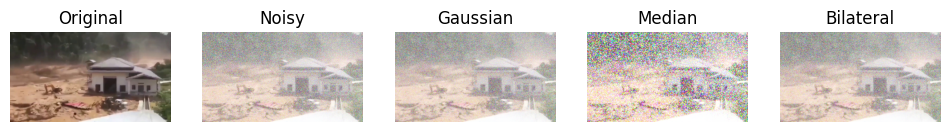

In [ ]:
# Add noise (simulation)
def add_noise(image):
    noise = np.random.normal(0, 25, image.shape).astype(np.uint8)
    noisy = cv2.add(image, noise)
    return noisy

noisy_img1 = add_noise(img1)

# Denoising techniques
gaussian = cv2.GaussianBlur(noisy_img1, (5,5), 0)
median = cv2.medianBlur(noisy_img1, 5)
bilateral = cv2.bilateralFilter(noisy_img1, 9, 75, 75)

# Show results
titles = ['Original', 'Noisy', 'Gaussian', 'Median', 'Bilateral']
images = [img1, noisy_img1, gaussian, median, bilateral]

plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()

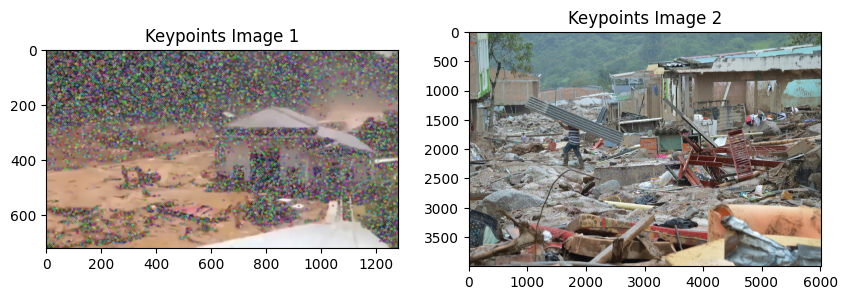

In [ ]:
# Convert to grayscale
gray1 = cv2.cvtColor(gaussian, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

# SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Draw keypoints
img_kp1 = cv2.drawKeypoints(img1, kp1, None)
img_kp2 = cv2.drawKeypoints(img2, kp2, None)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_kp1)
plt.title("Keypoints Image 1")

plt.subplot(1,2,2)
plt.imshow(img_kp2)
plt.title("Keypoints Image 2")
plt.show()

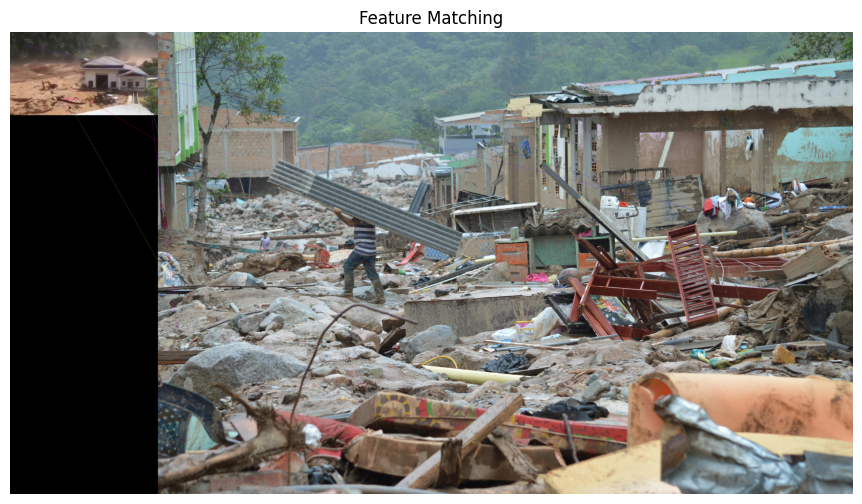

In [ ]:
# BF Matcher
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

# Apply ratio test (Lowe's test)
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Draw matches
matched_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, flags=2)

plt.figure(figsize=(12,6))
plt.imshow(matched_img)
plt.title("Feature Matching")
plt.axis('off')
plt.show()

**PART - 2**

In [ ]:
!pip install torch torchvision matplotlib opencv-python-headless

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving image2.jpeg to image2 (1).jpeg
Saving image1.jpg to image1 (1).jpg


In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models, transforms

# Load image
img = cv2.imread('image1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
# Load pretrained RetinaNet
model = models.detection.retinanet_resnet50_fpn(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(inplace=True)
          (downsample): Sequential(
            (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(256, eps=0.0)


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

img_tensor = transform(img_rgb)

In [ ]:
with torch.no_grad():
    predictions = model([img_tensor])

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

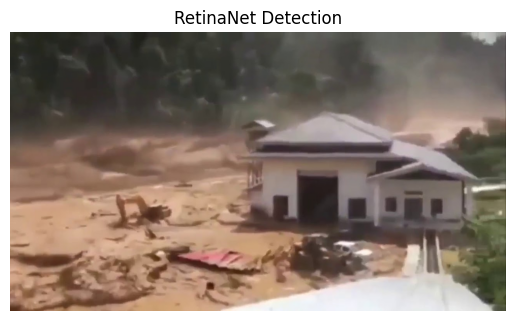

In [ ]:
def draw_boxes(image, preds, threshold=0.5):
    img_copy = image.copy()

    for box, score in zip(preds['boxes'], preds['scores']):
        if score > threshold:
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,255,0), 2)

    return img_copy

output_img = draw_boxes(img_rgb, predictions[0])

plt.imshow(output_img)
plt.title("RetinaNet Detection")
plt.axis('off')

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2-x1) * max(0, y2-y1)

    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])

    union = box1_area + box2_area - inter_area

    return inter_area / union

In [ ]:
# Example ground truth box
gt_box = [50, 50, 200, 200]

# Predicted box
pred_box = predictions[0]['boxes'][0].numpy()

iou = compute_iou(gt_box, pred_box)
print("IoU:", iou)

IoU: 0.0


In [ ]:
def add_noise(image):
    noise = np.random.normal(0, 50, image.shape).astype(np.uint8)
    return cv2.add(image, noise)

noisy_img = add_noise(img_rgb)

In [ ]:
blur_img = cv2.GaussianBlur(img_rgb, (11,11), 0)

In [ ]:
dark_img = (img_rgb * 0.3).astype(np.uint8)

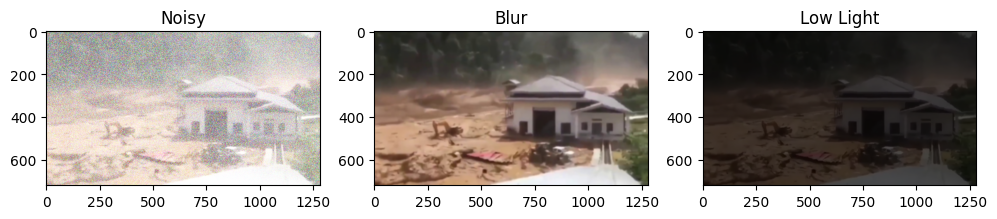

In [ ]:
def run_model(image):
    tensor = transform(image)
    with torch.no_grad():
        preds = model([tensor])
    return draw_boxes(image, preds[0])

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(run_model(noisy_img))
plt.title("Noisy")

plt.subplot(1,3,2)
plt.imshow(run_model(blur_img))
plt.title("Blur")

plt.subplot(1,3,3)
plt.imshow(run_model(dark_img))
plt.title("Low Light")

plt.show()